# SIT720 - Task 8.1D
## Sydney Housing Price Prediction and Decision Support System

### Part 1: Problem Definition and Data Collection

### Problem Definition

The aim of this project is to use machine learning to predict property sale prices in Burwood, Blacktown and Potts Point. The sale price is the target, while features such as suburb, property type, bedrooms, bathrooms, parking and property size may help predict the price.

I selected Burwood, Blacktown and Potts Point because they are three Sydney suburbs where I would consider buying a property. I was interested in these areas because they are diverse and multicultural, while also having different housing markets and property types. This makes them useful for comparing how location and property features can affect housing prices. Burwood has many apartments and units, Blacktown has more houses and townhouses, while Potts Point mainly has apartments. Using these suburbs gives me different types of properties to study how location and property features may affect sale prices.


### Data Collection

I manually collected sold property information from realestate.com.au for the three selected suburbs. The final dataset contains 120 sold properties, with 40 properties from Burwood, 40 from Blacktown and 40 from Potts Point.

For each property, I collected the sale price and available property information such as property type, bedrooms, bathrooms, parking, land size, floor area and year built. I also kept the listing URL as a reference to the original source.

In [94]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [95]:
# Loading the Sydney housing dataset from GitHub
data_url = "https://raw.githubusercontent.com/Afoteyfio/SIT720-Task-8.1D/main/data/s225674015_task_8.1D.xlsx"

housing_data = pd.read_excel(data_url)

# Displaying the first five rows
housing_data.head()

,Address,Suburb,Postcode,Sale_Price,Sale_Date,Property_Type,Bedrooms,Bathrooms,Parking,Land_Size_m2,Floor_Area_m2,Year_Built,Source,Listing_URL
0,1503/2A Elsie Street,Burwood,2134,1780000,2026-09-21,Apartment/Unit,3.0,2.0,2.0,154.0,NaN,NaN,realestate.com.au,https://www.realestate.com.au/sold/property-ns...
1,10/218-224 Wentworth Road,Burwood,2134,1330000,2026-09-17,Townhouse,4.0,2.0,1.0,NaN,248.0,1985.0,realestate.com.au,https://www.realestate.com.au/sold/property-ns...
2,9/18 Belmore Street,Burwood,2134,750000,2026-09-17,Apartment/Unit,2.0,1.0,1.0,NaN,85.0,NaN,realestate.com.au,https://www.realestate.com.au/sold/property-ns...
3,21/34-38 Park Avenue,Burwood,2134,880000,2026-09-14,Apartment/Unit,2.0,1.0,2.0,129.0,NaN,NaN,realestate.com.au,https://www.realestate.com.au/sold/property-ns...
4,43/12-16 Belmore Street,Burwood,2134,770000,2026-09-14,Apartment/Unit,2.0,1.0,1.0,96.0,NaN,NaN,realestate.com.au,https://www.realestate.com.au/sold/property-ns...


### Initial Dataset Inspection

I am checking the dataset to understand its size, the number of properties in each suburb, the data types and any missing values before preparing the data for modelling.

In [96]:
# Checking the size of the dataset
print("Dataset shape:", housing_data.shape)

# Checking the number of properties from each suburb
print("\nProperties by suburb:")
print(housing_data["Suburb"].value_counts())

Dataset shape: (120, 14)

Properties by suburb:
Suburb
Burwood        40
Blacktown      40
Potts Point    40
Name: count, dtype: int64


In [97]:
# Checking the data types of each column
housing_data.dtypes

,0
Address,object
Suburb,object
Postcode,int64
Sale_Price,int64
Sale_Date,datetime64[ns]
Property_Type,object
Bedrooms,float64
Bathrooms,float64
Parking,float64
Land_Size_m2,float64


In [98]:
# Checking missing values in each column
housing_data.isnull().sum()

,0
Address,0
Suburb,0
Postcode,0
Sale_Price,0
Sale_Date,1
Property_Type,0
Bedrooms,1
Bathrooms,1
Parking,1
Land_Size_m2,77


In [99]:
# Checking for duplicate rows
housing_data.duplicated().sum()

np.int64(0)

In [100]:
# Checking summary statistics for the numerical variables
housing_data.describe()

,Postcode,Sale_Price,Sale_Date,Bedrooms,Bathrooms,Parking,Land_Size_m2,Floor_Area_m2,Year_Built
count,120.000000,1.200000e+02,119,119.000000,119.000000,119.000000,43.000000,53.000000,19.000000
mean,2097.666667,1.119097e+06,2026-08-13 21:46:53.445378048,2.243697,1.521008,1.193277,384.115581,95.679245,1978.947368
min,2011.000000,3.750000e+05,2026-06-02 00:00:00,0.000000,1.000000,0.000000,63.000000,30.000000,1880.000000
25%,2011.000000,7.425000e+05,2026-07-23 00:00:00,1.000000,1.000000,1.000000,112.000000,54.000000,1950.000000
50%,2134.000000,9.237500e+05,2026-08-27 00:00:00,2.000000,1.000000,1.000000,306.500000,80.000000,1998.000000
75%,2148.000000,1.332500e+06,2026-09-11 00:00:00,3.000000,2.000000,1.500000,613.150000,108.000000,2013.500000
max,2148.000000,7.600000e+06,2026-09-23 00:00:00,7.000000,4.000000,6.000000,1182.400000,389.000000,2018.000000
std,61.806602,8.043457e+05,NaN,1.268700,0.674584,1.083601,277.804232,67.488111,39.840618


In [101]:
# Checking the number of each property type
housing_data["Property_Type"].value_counts()

,count
Property_Type,
Apartment/Unit,81
House,23
Townhouse,10
Duplex/Semi-detached,2
Studio,2
Terrace,2


### Data Quality and Limitations

The dataset has no duplicate rows and there are no missing values for the sale price. However, some property information is missing. Land size has 77 missing values, floor area has 67 missing values and year built has 101 missing values. There is also one missing value each for sale date, bedrooms, bathrooms and parking.

One challenge during data collection was that not every property listing provided the same information. This was more common for features such as land size, floor area and year built. I kept these values as missing instead of guessing them.

The dataset is also limited to 120 recently sold properties from three Sydney suburbs. This means the sample may not represent the whole Sydney housing market. Differences in property types between the suburbs may also affect the sale prices. There may also be some bias because the data only comes from realestate.com.au, and the three suburbs have different types of properties.

## Part 2: Data Understanding and Feature Engineering

### Housing Price Distribution

I am checking the distribution of sale prices to understand the property prices in the dataset.

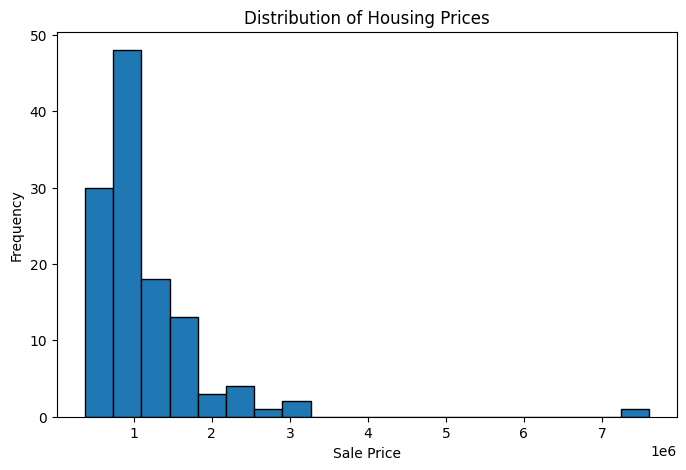

In [102]:
# Plotting the distribution of sale prices
plt.figure(figsize=(8, 5))
plt.hist(housing_data["Sale_Price"], bins=20, edgecolor="black")

plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.title("Distribution of Housing Prices")
plt.show()

The graph shows that most properties are in the lower price range. There are also a few properties with much higher prices, which may be possible outliers.

### Housing Prices by Suburb

I am comparing sale prices across the three suburbs to see how property prices differ between them.

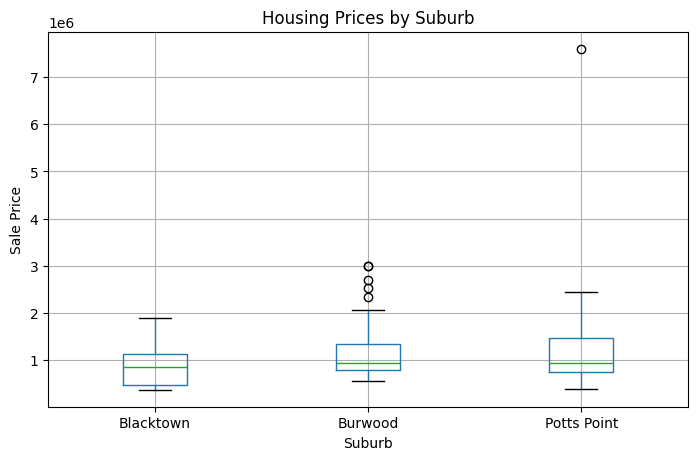

In [103]:
# Comparing sale prices by suburb
housing_data.boxplot(column="Sale_Price", by="Suburb", figsize=(8, 5))

plt.xlabel("Suburb")
plt.ylabel("Sale Price")
plt.title("Housing Prices by Suburb")
plt.suptitle("")
plt.show()

The three suburbs have similar median sale prices, but their price ranges are different. Burwood and Potts Point also have some higher-priced properties. Potts Point has one very high sale price that appears to be an outlier.

### Housing Prices Over Time

I am checking how sale prices change over time in the dataset.

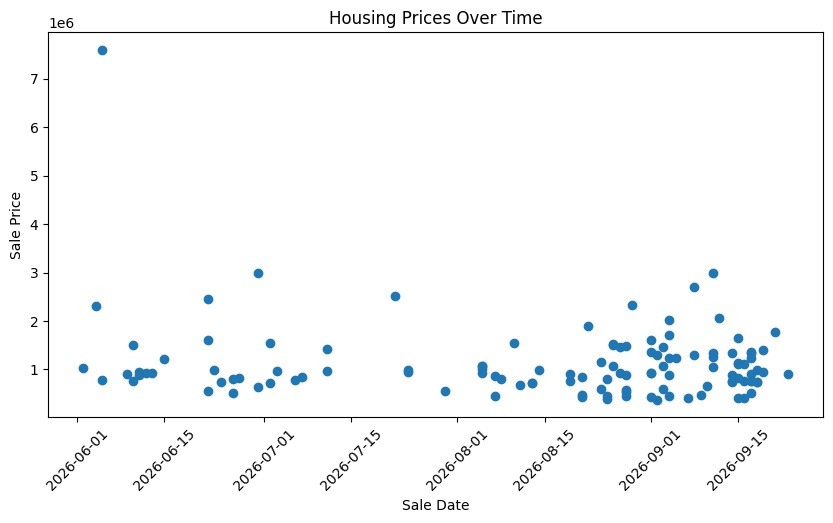

In [104]:
# Plotting sale prices over time
plt.figure(figsize=(10, 5))

plt.scatter(housing_data["Sale_Date"], housing_data["Sale_Price"])

plt.xlabel("Sale Date")
plt.ylabel("Sale Price")
plt.title("Housing Prices Over Time")
plt.xticks(rotation=45)
plt.show()

Most sale prices stay below AUD1.5 million over the period. There is no clear increase or decrease in prices over time. A few properties have much higher sale prices, including one very high value in June.

### Unusual Property Prices

I am checking the properties with the highest sale prices to understand the unusual values in the dataset.

In [105]:
# Checking properties with the highest sale prices
housing_data.nlargest(5, "Sale_Price")[
    ["Address", "Suburb", "Sale_Price", "Property_Type",
     "Bedrooms", "Bathrooms", "Parking"]
]

,Address,Suburb,Sale_Price,Property_Type,Bedrooms,Bathrooms,Parking
116,20 Rockwall Crescent,Potts Point,7600000,Terrace,4.0,3.0,2.0
6,14A Lindsay Street,Burwood,3000000,Duplex/Semi-detached,5.0,4.0,2.0
31,1702/2A Elsie Street,Burwood,3000000,Apartment/Unit,2.0,2.0,2.0
8,38 Stanley Street,Burwood,2700000,House,4.0,2.0,1.0
24,100 Wentworth Road,Burwood,2520000,House,4.0,2.0,2.0


The property in Potts Point has a much higher price than the others. I will keep it in the dataset for now and see how it affects the model later.

### Important Features

Suburb, property type and bedrooms are expected to have the strongest effect on sale price. The results show price differences between suburbs and property types, while properties with more bedrooms generally have higher prices.

### Sale Price by Property Type

In [106]:
# Checking sale prices by property type
housing_data.groupby("Property_Type")["Sale_Price"].agg(["mean", "median"])

,mean,median
Property_Type,,
Apartment/Unit,9.458596e+05,885000.0
Duplex/Semi-detached,2.665000e+06,2665000.0
House,1.419196e+06,1300000.0
Studio,4.675000e+05,467500.0
Terrace,4.950000e+06,4950000.0
Townhouse,8.870500e+05,785000.0


The table shows clear differences in sale prices between property types. Houses and duplexes generally have higher prices than apartments, townhouses and studios, showing that property type may affect sale price.

### Sale Price by Bedrooms

The average and median sale prices are compared by number of bedrooms.

In [107]:
# Checking sale prices by number of bedrooms
housing_data.groupby("Bedrooms")["Sale_Price"].agg(["mean", "median"])

,mean,median
Bedrooms,,
0.0,4.675000e+05,467500.0
1.0,8.813456e+05,890000.0
2.0,9.633268e+05,847500.0
3.0,1.247370e+06,1135000.0
4.0,2.517857e+06,1330000.0
5.0,1.572857e+06,1350000.0
6.0,1.405000e+06,1405000.0
7.0,1.900000e+06,1900000.0


Sale prices generally increase as the number of bedrooms increases. This suggests that bedrooms may be useful for predicting sale price.

### Preparing the Features

The missing values need to be handled before using the data for modelling.

In [108]:
# Checking missing values in the useful features
housing_data[
    ["Suburb", "Property_Type", "Bedrooms", "Bathrooms",
     "Parking", "Land_Size_m2", "Floor_Area_m2", "Year_Built"]
].isnull().sum()

,0
Suburb,0
Property_Type,0
Bedrooms,1
Bathrooms,1
Parking,1
Land_Size_m2,77
Floor_Area_m2,67
Year_Built,101


Year built, land size and floor area have many missing values, so they will not be used for now. The few missing values in bedrooms, bathrooms and parking will be replaced with the median.

In [109]:
# Filling the missing values with the median
housing_data["Bedrooms"] = housing_data["Bedrooms"].fillna(housing_data["Bedrooms"].median())
housing_data["Bathrooms"] = housing_data["Bathrooms"].fillna(housing_data["Bathrooms"].median())
housing_data["Parking"] = housing_data["Parking"].fillna(housing_data["Parking"].median())

# Checking the missing values
housing_data[["Bedrooms", "Bathrooms", "Parking"]].isnull().sum()

,0
Bedrooms,0
Bathrooms,0
Parking,0


### Encoding Categorical Features

Suburb and property type need to be converted into numerical values.

In [110]:
# Encoding suburb and property type
housing_encoded = pd.get_dummies(
    housing_data,
    columns=["Suburb", "Property_Type"],
    dtype=int
)

housing_encoded.head()

,Address,Postcode,Sale_Price,Sale_Date,Bedrooms,Bathrooms,Parking,Land_Size_m2,Floor_Area_m2,Year_Built,...,Listing_URL,Suburb_Blacktown,Suburb_Burwood,Suburb_Potts Point,Property_Type_Apartment/Unit,Property_Type_Duplex/Semi-detached,Property_Type_House,Property_Type_Studio,Property_Type_Terrace,Property_Type_Townhouse
0,1503/2A Elsie Street,2134,1780000,2026-09-21,3.0,2.0,2.0,154.0,NaN,NaN,...,https://www.realestate.com.au/sold/property-ns...,0,1,0,1,0,0,0,0,0
1,10/218-224 Wentworth Road,2134,1330000,2026-09-17,4.0,2.0,1.0,NaN,248.0,1985.0,...,https://www.realestate.com.au/sold/property-ns...,0,1,0,0,0,0,0,0,1
2,9/18 Belmore Street,2134,750000,2026-09-17,2.0,1.0,1.0,NaN,85.0,NaN,...,https://www.realestate.com.au/sold/property-ns...,0,1,0,1,0,0,0,0,0
3,21/34-38 Park Avenue,2134,880000,2026-09-14,2.0,1.0,2.0,129.0,NaN,NaN,...,https://www.realestate.com.au/sold/property-ns...,0,1,0,1,0,0,0,0,0
4,43/12-16 Belmore Street,2134,770000,2026-09-14,2.0,1.0,1.0,96.0,NaN,NaN,...,https://www.realestate.com.au/sold/property-ns...,0,1,0,1,0,0,0,0,0


### Selecting Features

The useful features are selected for modelling.

In [111]:
# Selecting the features for modelling
features = [
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Suburb_Blacktown",
    "Suburb_Burwood",
    "Suburb_Potts Point",
    "Property_Type_Apartment/Unit",
    "Property_Type_Duplex/Semi-detached",
    "Property_Type_House",
    "Property_Type_Studio",
    "Property_Type_Terrace",
    "Property_Type_Townhouse"
]

X = housing_encoded[features]
y = housing_encoded["Sale_Price"]

# Checking the feature data
X.head()

,Bedrooms,Bathrooms,Parking,Suburb_Blacktown,Suburb_Burwood,Suburb_Potts Point,Property_Type_Apartment/Unit,Property_Type_Duplex/Semi-detached,Property_Type_House,Property_Type_Studio,Property_Type_Terrace,Property_Type_Townhouse
0,3.0,2.0,2.0,0,1,0,1,0,0,0,0,0
1,4.0,2.0,1.0,0,1,0,0,0,0,0,0,1
2,2.0,1.0,1.0,0,1,0,1,0,0,0,0,0
3,2.0,1.0,2.0,0,1,0,1,0,0,0,0,0
4,2.0,1.0,1.0,0,1,0,1,0,0,0,0,0


#### Feature Engineering Reflection

The results support the selected features. Sale prices changed across suburbs and property types, and properties with more bedrooms generally had higher prices. The selected features therefore match the patterns found in the data.

More complete information about land size, floor area and year built may improve the predictions. These features were not used because too many values were missing from the dataset.

## Part 3: Model Development and Evaluation

### Model Selection

Three regression models will be compared: Linear Regression, Decision Tree Regression and Random Forest Regression.

Linear Regression will be used as a simple starting model. It is easy to understand, but it may not capture complex relationships between the property features and sale price.

Decision Tree Regression can handle more complex relationships in the data. However, it can also overfit the training data if the tree becomes too complex.

Random Forest Regression uses multiple decision trees instead of one. This may give more stable predictions and reduce some of the problems of using a single tree, but it is also a more complex model.

Before training the models, Random Forest Regression is expected to perform best because housing prices may be influenced by several property features in different ways.

### Training and Test Data

The data is split into training and test sets. The training data will be used for model development and cross-validation, while the test data will be kept separate for later evaluation.

In [112]:
# Importing train_test_split
from sklearn.model_selection import train_test_split

# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Checking the size of each set
print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

Training data: (96, 12)
Test data: (24, 12)


### K-Fold Cross-Validation

K-fold cross-validation will be used to evaluate the three models. The training data will be divided into 5 folds so that each model can be tested on different parts of the training data.

In [113]:
# Importing KFold
from sklearn.model_selection import KFold

# Setting up 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("Number of folds:", kfold.get_n_splits())

Number of folds: 5


### Linear Regression

Linear Regression will be used as the first model. It provides a simple approach for predicting sale price and will give a baseline to compare with the more complex models.

In [114]:
# Importing Linear Regression and cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Creating the Linear Regression model
linear_model = LinearRegression()

# Evaluating the model using 5-fold cross-validation
linear_scores = cross_val_score(
    linear_model,
    X_train,
    y_train,
    cv=kfold,
    scoring="neg_mean_absolute_error"
)

# Converting the scores to positive MAE values
linear_mae = -linear_scores

print("MAE for each fold:", linear_mae)
print("Mean MAE:", linear_mae.mean())

MAE for each fold: [198438.99264073 253217.99243035 449315.83380723 521077.16579009
 488078.05012271]
Mean MAE: 382025.6069582233


### Decision Tree Regression

Decision Tree Regression can model more complex relationships between the property features and sale price. It will be compared with Linear Regression to see whether a more flexible model improves the predictions.

In [115]:
# Importing Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor

# Creating the Decision Tree model
tree_model = DecisionTreeRegressor(random_state=42)

# Evaluating the model using 5-fold cross-validation
tree_scores = cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=kfold,
    scoring="neg_mean_absolute_error"
)

# Converting the scores to positive MAE values
tree_mae = -tree_scores

print("MAE for each fold:", tree_mae)
print("Mean MAE:", tree_mae.mean())

MAE for each fold: [169605.55555556 235060.72681704 352436.49122807 429280.70175439
 507695.0877193 ]
Mean MAE: 338815.7126148705


### Random Forest Regression

Random Forest Regression uses multiple decision trees to make predictions. It may give more stable predictions than using a single decision tree.

In [116]:
# Importing Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

# Creating the Random Forest model
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Evaluating the model using 5-fold cross-validation
forest_scores = cross_val_score(
    forest_model,
    X_train,
    y_train,
    cv=kfold,
    scoring="neg_mean_absolute_error"
)

# Converting the scores to positive MAE values
forest_mae = -forest_scores

print("MAE for each fold:", forest_mae)
print("Mean MAE:", forest_mae.mean())

MAE for each fold: [159351.88413864 219349.49191837 372654.90352396 514983.42154698
 383023.59576495]
Mean MAE: 329872.6593785819


### Model Evaluation

The models will be compared using MAE, RMSE and R². Lower MAE and RMSE values show smaller prediction errors, while a higher R² shows that the model explains more of the variation in sale prices.

In [117]:
# Calculating RMSE for each model
linear_rmse = np.sqrt(-cross_val_score(
    linear_model, X_train, y_train,
    cv=kfold, scoring="neg_mean_squared_error"
))

tree_rmse = np.sqrt(-cross_val_score(
    tree_model, X_train, y_train,
    cv=kfold, scoring="neg_mean_squared_error"
))

forest_rmse = np.sqrt(-cross_val_score(
    forest_model, X_train, y_train,
    cv=kfold, scoring="neg_mean_squared_error"
))

print("Linear Regression Mean RMSE:", linear_rmse.mean())
print("Decision Tree Mean RMSE:", tree_rmse.mean())
print("Random Forest Mean RMSE:", forest_rmse.mean())

Linear Regression Mean RMSE: 750112.572249773
Decision Tree Mean RMSE: 755593.3015511535
Random Forest Mean RMSE: 684494.2759427533


In [118]:
# Calculating R-squared for each model
linear_r2 = cross_val_score(
    linear_model, X_train, y_train,
    cv=kfold, scoring="r2"
)

tree_r2 = cross_val_score(
    tree_model, X_train, y_train,
    cv=kfold, scoring="r2"
)

forest_r2 = cross_val_score(
    forest_model, X_train, y_train,
    cv=kfold, scoring="r2"
)

print("Linear Regression Mean R2:", linear_r2.mean())
print("Decision Tree Mean R2:", tree_r2.mean())
print("Random Forest Mean R2:", forest_r2.mean())

Linear Regression Mean R2: -0.6779318292214358
Decision Tree Mean R2: -0.7252504512430121
Random Forest Mean R2: -0.15075356458986383


In [119]:
# Creating a table to compare the models
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Mean MAE": [
        linear_mae.mean(),
        tree_mae.mean(),
        forest_mae.mean()
    ],
    "Mean RMSE": [
        linear_rmse.mean(),
        tree_rmse.mean(),
        forest_rmse.mean()
    ],
    "Mean R2": [
        linear_r2.mean(),
        tree_r2.mean(),
        forest_r2.mean()
    ]
})

results

,Model,Mean MAE,Mean RMSE,Mean R2
0,Linear Regression,382025.606958,750112.572250,-0.677932
1,Decision Tree,338815.712615,755593.301551,-0.725250
2,Random Forest,329872.659379,684494.275943,-0.150754


### Model Behaviour

The training performance will be compared with the cross-validation performance to check whether the models show signs of underfitting or overfitting.

In [120]:
# Checking training performance for each model
from sklearn.metrics import mean_absolute_error

models = {
    "Linear Regression": linear_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

for name, model in models.items():
    model.fit(X_train, y_train)
    train_predictions = model.predict(X_train)
    train_mae = mean_absolute_error(y_train, train_predictions)

    print(name, "Training MAE:", train_mae)

Linear Regression Training MAE: 259509.83099445523
Decision Tree Training MAE: 97297.01097105508
Random Forest Training MAE: 161273.22729737408


The Decision Tree has a much lower training error than its cross-validation error. This suggests that it may be overfitting the training data.

Random Forest also has a lower training error, but it performs better during cross-validation. Linear Regression has a higher error, which suggests that it may be too simple for the housing data.

Overall, the results show that model complexity affects performance. The Decision Tree is more likely to overfit, while Random Forest gives better overall cross-validation results.

### Test Set Evaluation

The three models are now evaluated on the test data that was kept separate from the model development process.

In [121]:
# Evaluating the models on the test data
from sklearn.metrics import mean_squared_error, r2_score

for name, model in models.items():
    test_predictions = model.predict(X_test)

    test_mae = mean_absolute_error(y_test, test_predictions)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
    test_r2 = r2_score(y_test, test_predictions)

    print(name)
    print("MAE:", test_mae)
    print("RMSE:", test_rmse)
    print("R2:", test_r2)
    print()

Linear Regression
MAE: 336932.5914395183
RMSE: 517575.12082313566
R2: 0.1294070761766426

Decision Tree
MAE: 263387.4638188609
RMSE: 488759.82390461134
R2: 0.2236467992481097

Random Forest
MAE: 276016.5655259487
RMSE: 480871.2000870026
R2: 0.24850536670430423



### Model Comparison

Random Forest performed best overall during cross-validation. It had the lowest MAE and RMSE and the highest R² of the three models. However, the R² values were still negative, showing that all three models had difficulty predicting some of the housing prices.

On the test data, the Decision Tree had a slightly lower MAE, while Random Forest had a lower RMSE and a higher R². The Decision Tree also showed more signs of overfitting because its training error was much lower than its cross-validation error.

The results mostly support my original expectation that Random Forest would perform best. I selected Random Forest as the final model because it gave the best overall cross-validation results. The small dataset, missing property information and unusual high-priced properties may have affected the model's performance.

## Part 4: Investigating Prediction Failures

The five properties with the largest prediction errors will be examined to understand where the Random Forest model had difficulty predicting sale prices.

In [122]:
# Predicting sale prices for the test data
forest_predictions = forest_model.predict(X_test)

# Creating a table with the actual and predicted prices
prediction_errors = housing_data.loc[X_test.index, [
    "Address",
    "Suburb",
    "Property_Type",
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Sale_Price"
]].copy()

prediction_errors["Predicted_Price"] = forest_predictions

# Calculating the prediction error
prediction_errors["Absolute_Error"] = abs(
    prediction_errors["Sale_Price"] -
    prediction_errors["Predicted_Price"]
)

# Showing the five largest prediction errors
largest_errors = prediction_errors.nlargest(5, "Absolute_Error")

largest_errors

,Address,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Sale_Price,Predicted_Price,Absolute_Error
31,1702/2A Elsie Street,Burwood,Apartment/Unit,2.0,2.0,2.0,3000000,1.017389e+06,1.982611e+06
55,42 Burke Street,Blacktown,House,5.0,3.0,6.0,1260000,1.894927e+06,6.349267e+05
0,1503/2A Elsie Street,Burwood,Apartment/Unit,3.0,2.0,2.0,1780000,1.279822e+06,5.001783e+05
44,40 Stephen Street,Blacktown,House,5.0,3.0,3.0,1350000,1.844277e+06,4.942767e+05
40,84-84A Duckmallois Avenue,Blacktown,House,6.0,3.0,3.0,1405000,1.852577e+06,4.475767e+05



### Largest Prediction Errors

I am checking the five properties with the largest prediction errors to see where the model had difficulty.

In [123]:
# Displaying the five largest errors in a clearer format
error_table = largest_errors.copy()

error_table["Sale_Price"] = error_table["Sale_Price"].round(0)
error_table["Predicted_Price"] = error_table["Predicted_Price"].round(0)
error_table["Absolute_Error"] = error_table["Absolute_Error"].round(0)

error_table

,Address,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Sale_Price,Predicted_Price,Absolute_Error
31,1702/2A Elsie Street,Burwood,Apartment/Unit,2.0,2.0,2.0,3000000,1017389.0,1982611.0
55,42 Burke Street,Blacktown,House,5.0,3.0,6.0,1260000,1894927.0,634927.0
0,1503/2A Elsie Street,Burwood,Apartment/Unit,3.0,2.0,2.0,1780000,1279822.0,500178.0
44,40 Stephen Street,Blacktown,House,5.0,3.0,3.0,1350000,1844277.0,494277.0
40,84-84A Duckmallois Avenue,Blacktown,House,6.0,3.0,3.0,1405000,1852577.0,447577.0


In [124]:
# Checking more information about the five properties
housing_data.loc[largest_errors.index, [
    "Address",
    "Suburb",
    "Property_Type",
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Land_Size_m2",
    "Floor_Area_m2",
    "Year_Built",
    "Sale_Price"
]]

,Address,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Land_Size_m2,Floor_Area_m2,Year_Built,Sale_Price
31,1702/2A Elsie Street,Burwood,Apartment/Unit,2.0,2.0,2.0,243.0,217.0,NaN,3000000
55,42 Burke Street,Blacktown,House,5.0,3.0,6.0,626.0,183.0,1950.0,1260000
0,1503/2A Elsie Street,Burwood,Apartment/Unit,3.0,2.0,2.0,154.0,NaN,NaN,1780000
44,40 Stephen Street,Blacktown,House,5.0,3.0,3.0,338.0,NaN,NaN,1350000
40,84-84A Duckmallois Avenue,Blacktown,House,6.0,3.0,3.0,701.0,NaN,NaN,1405000


### Looking at the Five Properties

Some of the properties have information that was not used by the model, such as land size, floor area and year built. This may help explain some of the large prediction errors.

### Individual Prediction Errors

1702/2A Elsie Street had the largest error at about AUD 1.98 million. It sold for AUD 3,000,000, but the model predicted about AUD 1,017,389. It has 2 bedrooms and a floor area of 217 m². Floor area was not used by the model, which may help explain the large difference.

42 Burke Street had an error of about AUD 635,000. It sold for AUD 1,260,000, while the model predicted about AUD 1,894,927. The property has 5 bedrooms, 3 bathrooms and 6 parking spaces. These features may have contributed to the higher prediction.

1503/2A Elsie Street had an error of about AUD 500,000. It sold for AUD 1,780,000, while the model predicted about AUD 1,279,822. It is a 3-bedroom apartment in Burwood. Floor area and year built were missing, so the model had less information about this property.

40 Stephen Street had an error of about AUD 494,000. It sold for AUD 1,350,000, but the model predicted about AUD 1,844,277. It has 5 bedrooms and 3 bathrooms, but information such as floor area and year built was missing.

84-84A Duckmallois Avenue had an error of about AUD 448,000. It sold for AUD 1,405,000, while the model predicted about AUD 1,852,577. It has 6 bedrooms and 3 bathrooms. The high number of bedrooms may have contributed to the higher prediction.

### Model Limitations

The model only uses suburb, property type, bedrooms, bathrooms and parking. Other information such as land size, floor area and year built was not used because many values were missing. Details about the condition of the property, renovations and exact location were also not available.

The five largest errors show that unusual properties can be harder to predict. In these results, large houses with many bedrooms and unusually expensive apartments had some of the biggest errors. There may not be enough similar properties in the dataset for the model to learn from.

Because of this, the predictions should be used carefully when a property is very different from the others in the dataset. A larger dataset with more complete property information may help improve the predictions.

## Part 5: Human Judgement, Machine Learning, and Large Language Models

I will be using 10 properties from the test data to compare three different ways of estimating their sale prices. These are the Random Forest model, a large language model and my own estimates. I will then compare the three estimates with the actual sale prices.

In [125]:
# Selecting 10 properties from the test data
selected_properties = X_test.head(10)

# Getting the original property information
part5_properties = housing_data.loc[selected_properties.index, [
    "Address",
    "Suburb",
    "Property_Type",
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Sale_Price"
]].copy()

part5_properties

,Address,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Sale_Price
44,40 Stephen Street,Blacktown,House,5.0,3.0,3.0,1350000
47,6 Oregon Street,Blacktown,House,3.0,1.0,3.0,1105000
4,43/12-16 Belmore Street,Burwood,Apartment/Unit,2.0,1.0,1.0,770000
55,42 Burke Street,Blacktown,House,5.0,3.0,6.0,1260000
26,507/65 Shaftesbury Road,Burwood,Apartment/Unit,2.0,2.0,1.0,850000
64,1103/5 Second Avenue,Blacktown,Apartment/Unit,2.0,2.0,1.0,420000
73,903/5 Second Avenue,Blacktown,Apartment/Unit,3.0,2.0,2.0,600000
10,73 Liverpool Road,Burwood,House,3.0,1.0,4.0,1700000
40,84-84A Duckmallois Avenue,Blacktown,House,6.0,3.0,3.0,1405000
107,42/19A Tusculum Street,Potts Point,Apartment/Unit,1.0,1.0,0.0,637500


### Random Forest Predictions

I will first use the Random Forest model to predict the sale prices of the 10 selected properties.

In [126]:
# Predicting the prices of the 10 selected properties
part5_predictions = forest_model.predict(selected_properties)

# Adding the predictions to the table
part5_properties["Random_Forest_Prediction"] = part5_predictions

part5_properties

,Address,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Sale_Price,Random_Forest_Prediction
44,40 Stephen Street,Blacktown,House,5.0,3.0,3.0,1350000,1.844277e+06
47,6 Oregon Street,Blacktown,House,3.0,1.0,3.0,1105000,1.041023e+06
4,43/12-16 Belmore Street,Burwood,Apartment/Unit,2.0,1.0,1.0,770000,7.880607e+05
55,42 Burke Street,Blacktown,House,5.0,3.0,6.0,1260000,1.894927e+06
26,507/65 Shaftesbury Road,Burwood,Apartment/Unit,2.0,2.0,1.0,850000,9.590473e+05
64,1103/5 Second Avenue,Blacktown,Apartment/Unit,2.0,2.0,1.0,420000,4.768403e+05
73,903/5 Second Avenue,Blacktown,Apartment/Unit,3.0,2.0,2.0,600000,7.217104e+05
10,73 Liverpool Road,Burwood,House,3.0,1.0,4.0,1700000,1.867757e+06
40,84-84A Duckmallois Avenue,Blacktown,House,6.0,3.0,3.0,1405000,1.852577e+06
107,42/19A Tusculum Street,Potts Point,Apartment/Unit,1.0,1.0,0.0,637500,8.226930e+05


### LLM Estimates

I used ChatGPT to estimate the prices of the same 10 properties. I provided the same property features used by the Random Forest model: suburb, property type, bedrooms, bathrooms and parking. The actual sale prices and Random Forest predictions were not provided to ChatGPT.

In [127]:
# Adding the ChatGPT estimates
llm_estimates = [
    1250000,
    900000,
    850000,
    1300000,
    930000,
    600000,
    720000,
    1750000,
    1350000,
    750000
]

part5_properties["LLM_Estimate"] = llm_estimates

part5_properties

,Address,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Sale_Price,Random_Forest_Prediction,LLM_Estimate
44,40 Stephen Street,Blacktown,House,5.0,3.0,3.0,1350000,1.844277e+06,1250000
47,6 Oregon Street,Blacktown,House,3.0,1.0,3.0,1105000,1.041023e+06,900000
4,43/12-16 Belmore Street,Burwood,Apartment/Unit,2.0,1.0,1.0,770000,7.880607e+05,850000
55,42 Burke Street,Blacktown,House,5.0,3.0,6.0,1260000,1.894927e+06,1300000
26,507/65 Shaftesbury Road,Burwood,Apartment/Unit,2.0,2.0,1.0,850000,9.590473e+05,930000
64,1103/5 Second Avenue,Blacktown,Apartment/Unit,2.0,2.0,1.0,420000,4.768403e+05,600000
73,903/5 Second Avenue,Blacktown,Apartment/Unit,3.0,2.0,2.0,600000,7.217104e+05,720000
10,73 Liverpool Road,Burwood,House,3.0,1.0,4.0,1700000,1.867757e+06,1750000
40,84-84A Duckmallois Avenue,Blacktown,House,6.0,3.0,3.0,1405000,1.852577e+06,1350000
107,42/19A Tusculum Street,Potts Point,Apartment/Unit,1.0,1.0,0.0,637500,8.226930e+05,750000


### My Own Estimates

I estimated the prices of the same 10 properties based on the suburb, property type, bedrooms, bathrooms and parking, together with what I learned from exploring the housing data.

In [128]:
# Adding my own price estimates
my_estimates = [
    1300000,
    1000000,
    850000,
    1400000,
    950000,
    500000,
    650000,
    3500000,
    1800000,
    600000
]

part5_properties["My_Estimate"] = my_estimates

part5_properties

,Address,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Sale_Price,Random_Forest_Prediction,LLM_Estimate,My_Estimate
44,40 Stephen Street,Blacktown,House,5.0,3.0,3.0,1350000,1.844277e+06,1250000,1300000
47,6 Oregon Street,Blacktown,House,3.0,1.0,3.0,1105000,1.041023e+06,900000,1000000
4,43/12-16 Belmore Street,Burwood,Apartment/Unit,2.0,1.0,1.0,770000,7.880607e+05,850000,850000
55,42 Burke Street,Blacktown,House,5.0,3.0,6.0,1260000,1.894927e+06,1300000,1400000
26,507/65 Shaftesbury Road,Burwood,Apartment/Unit,2.0,2.0,1.0,850000,9.590473e+05,930000,950000
64,1103/5 Second Avenue,Blacktown,Apartment/Unit,2.0,2.0,1.0,420000,4.768403e+05,600000,500000
73,903/5 Second Avenue,Blacktown,Apartment/Unit,3.0,2.0,2.0,600000,7.217104e+05,720000,650000
10,73 Liverpool Road,Burwood,House,3.0,1.0,4.0,1700000,1.867757e+06,1750000,3500000
40,84-84A Duckmallois Avenue,Blacktown,House,6.0,3.0,3.0,1405000,1.852577e+06,1350000,1800000
107,42/19A Tusculum Street,Potts Point,Apartment/Unit,1.0,1.0,0.0,637500,8.226930e+05,750000,600000


In [129]:
# Calculating the absolute errors
part5_properties["RF_Error"] = abs(
    part5_properties["Sale_Price"] -
    part5_properties["Random_Forest_Prediction"]
)

part5_properties["LLM_Error"] = abs(
    part5_properties["Sale_Price"] -
    part5_properties["LLM_Estimate"]
)

part5_properties["My_Error"] = abs(
    part5_properties["Sale_Price"] -
    part5_properties["My_Estimate"]
)

part5_properties

,Address,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Sale_Price,Random_Forest_Prediction,LLM_Estimate,My_Estimate,RF_Error,LLM_Error,My_Error
44,40 Stephen Street,Blacktown,House,5.0,3.0,3.0,1350000,1.844277e+06,1250000,1300000,494276.666667,100000,50000
47,6 Oregon Street,Blacktown,House,3.0,1.0,3.0,1105000,1.041023e+06,900000,1000000,63977.083333,205000,105000
4,43/12-16 Belmore Street,Burwood,Apartment/Unit,2.0,1.0,1.0,770000,7.880607e+05,850000,850000,18060.718449,80000,80000
55,42 Burke Street,Blacktown,House,5.0,3.0,6.0,1260000,1.894927e+06,1300000,1400000,634926.666667,40000,140000
26,507/65 Shaftesbury Road,Burwood,Apartment/Unit,2.0,2.0,1.0,850000,9.590473e+05,930000,950000,109047.253543,80000,100000
64,1103/5 Second Avenue,Blacktown,Apartment/Unit,2.0,2.0,1.0,420000,4.768403e+05,600000,500000,56840.273810,180000,80000
73,903/5 Second Avenue,Blacktown,Apartment/Unit,3.0,2.0,2.0,600000,7.217104e+05,720000,650000,121710.416667,120000,50000
10,73 Liverpool Road,Burwood,House,3.0,1.0,4.0,1700000,1.867757e+06,1750000,3500000,167756.760000,50000,1800000
40,84-84A Duckmallois Avenue,Blacktown,House,6.0,3.0,3.0,1405000,1.852577e+06,1350000,1800000,447576.666667,55000,395000
107,42/19A Tusculum Street,Potts Point,Apartment/Unit,1.0,1.0,0.0,637500,8.226930e+05,750000,600000,185193.023564,112500,37500


In [130]:
# Calculating the average error for each approach
comparison_mae = pd.DataFrame({
    "Approach": ["Random Forest", "LLM", "My Estimate"],
    "MAE": [
        part5_properties["RF_Error"].mean(),
        part5_properties["LLM_Error"].mean(),
        part5_properties["My_Error"].mean()
    ]
})

comparison_mae

,Approach,MAE
0,Random Forest,229936.552937
1,LLM,102250.000000
2,My Estimate,283750.000000


In [131]:
# Finding which approach was closest for each property
part5_properties["Best_Approach"] = part5_properties[
    ["RF_Error", "LLM_Error", "My_Error"]
].idxmin(axis=1)

part5_properties[[
    "Address",
    "Sale_Price",
    "RF_Error",
    "LLM_Error",
    "My_Error",
    "Best_Approach"
]]

,Address,Sale_Price,RF_Error,LLM_Error,My_Error,Best_Approach
44,40 Stephen Street,1350000,494276.666667,100000,50000,My_Error
47,6 Oregon Street,1105000,63977.083333,205000,105000,RF_Error
4,43/12-16 Belmore Street,770000,18060.718449,80000,80000,RF_Error
55,42 Burke Street,1260000,634926.666667,40000,140000,LLM_Error
26,507/65 Shaftesbury Road,850000,109047.253543,80000,100000,LLM_Error
64,1103/5 Second Avenue,420000,56840.273810,180000,80000,RF_Error
73,903/5 Second Avenue,600000,121710.416667,120000,50000,My_Error
10,73 Liverpool Road,1700000,167756.760000,50000,1800000,LLM_Error
40,84-84A Duckmallois Avenue,1405000,447576.666667,55000,395000,LLM_Error
107,42/19A Tusculum Street,637500,185193.023564,112500,37500,My_Error


### Comparison of the Results

The LLM had the lowest average error at about AUD 102,250. Random Forest had an average error of about AUD 229,937, while my estimates had the highest at about AUD 283,750.

The results were not the same for every property. Random Forest was closest for 3 properties, the LLM for 4, and my estimates for 3.

The LLM was only AUD 50,000 away from the actual price of 73 Liverpool Road. Random Forest was very close for 43/12-16 Belmore Street, with an error of about AUD 18,061.

Some of my estimates were also close. My estimate for 42/19A Tusculum Street was only AUD 37,500 away. However, I estimated 73 Liverpool Road much too high, which increased my overall error.

### Strengths and Weaknesses

Random Forest uses patterns from the training data to predict house prices. It gives consistent results, but it can struggle when a property is different from the properties in the training data.

The LLM had the lowest average error for these 10 properties. It was able to give reasonable estimates using the property information provided. However, the estimates may change depending on the information and prompt given to the LLM.

My own estimates were accurate for some properties but not for others. Human judgement can still be useful because a person can use their understanding of the housing market when making an estimate. However, personal judgement can also lead to large errors.

Overall, each approach had its strengths and weaknesses. For these 10 properties, the LLM had the lowest average error, but no approach was the most accurate for every property.

## Part 6: Final Deployment and Reflection

The final Random Forest model will be used in a simple web application where a user can enter property information and receive an estimated sale price.

In [132]:
# Saving the Random Forest model
import joblib

joblib.dump(forest_model, "random_forest_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [134]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Loading the saved model
model = joblib.load("random_forest_model.pkl")

st.title("Sydney Housing Price Predictor")

st.write("Enter the property information below to estimate the sale price.")

# Property inputs
suburb = st.selectbox(
    "Suburb",
    ["Blacktown", "Burwood", "Potts Point"]
)

property_type = st.selectbox(
    "Property Type",
    ["Apartment/Unit", "Duplex/Semi-detached", "House",
     "Studio", "Terrace", "Townhouse"]
)

bedrooms = st.number_input("Bedrooms", min_value=0, max_value=10, value=2)
bathrooms = st.number_input("Bathrooms", min_value=0, max_value=10, value=1)
parking = st.number_input("Parking", min_value=0, max_value=10, value=1)

# Predicting the sale price
if st.button("Predict Sale Price"):

    input_data = pd.DataFrame({
        "Bedrooms": [bedrooms],
        "Bathrooms": [bathrooms],
        "Parking": [parking],
        "Suburb_Blacktown": [int(suburb == "Blacktown")],
        "Suburb_Burwood": [int(suburb == "Burwood")],
        "Suburb_Potts Point": [int(suburb == "Potts Point")],
        "Property_Type_Apartment/Unit": [int(property_type == "Apartment/Unit")],
        "Property_Type_Duplex/Semi-detached": [int(property_type == "Duplex/Semi-detached")],
        "Property_Type_House": [int(property_type == "House")],
        "Property_Type_Studio": [int(property_type == "Studio")],
        "Property_Type_Terrace": [int(property_type == "Terrace")],
        "Property_Type_Townhouse": [int(property_type == "Townhouse")]
    })

    prediction = model.predict(input_data)[0]

    st.write(f"Estimated Sale Price: AUD {prediction:,.0f}")

Overwriting app.py


In [135]:
# Installing Streamlit
!pip install streamlit -q

In [136]:
# Running the Streamlit app
!streamlit run app.py \
    --server.port 8501 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    &>/content/logs.txt &

In [137]:
from google.colab import output

output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

### Application Development and Instructions

I developed a simple web application using Streamlit. The application uses the Random Forest model developed earlier in the project. The trained model was saved using joblib and loaded into the Streamlit application.

The user selects the suburb and property type, then enters the number of bedrooms, bathrooms and parking spaces. These inputs are converted into the same format used to train the model. When the user clicks the Predict Sale Price button, the Random Forest model predicts the property price and displays the result in AUD.

To use the application:
1. Select a suburb.
2. Select the property type.
3. Enter the number of bedrooms, bathrooms and parking spaces.
4. Click **Predict Sale Price**.
5. The estimated sale price will be displayed below the button.

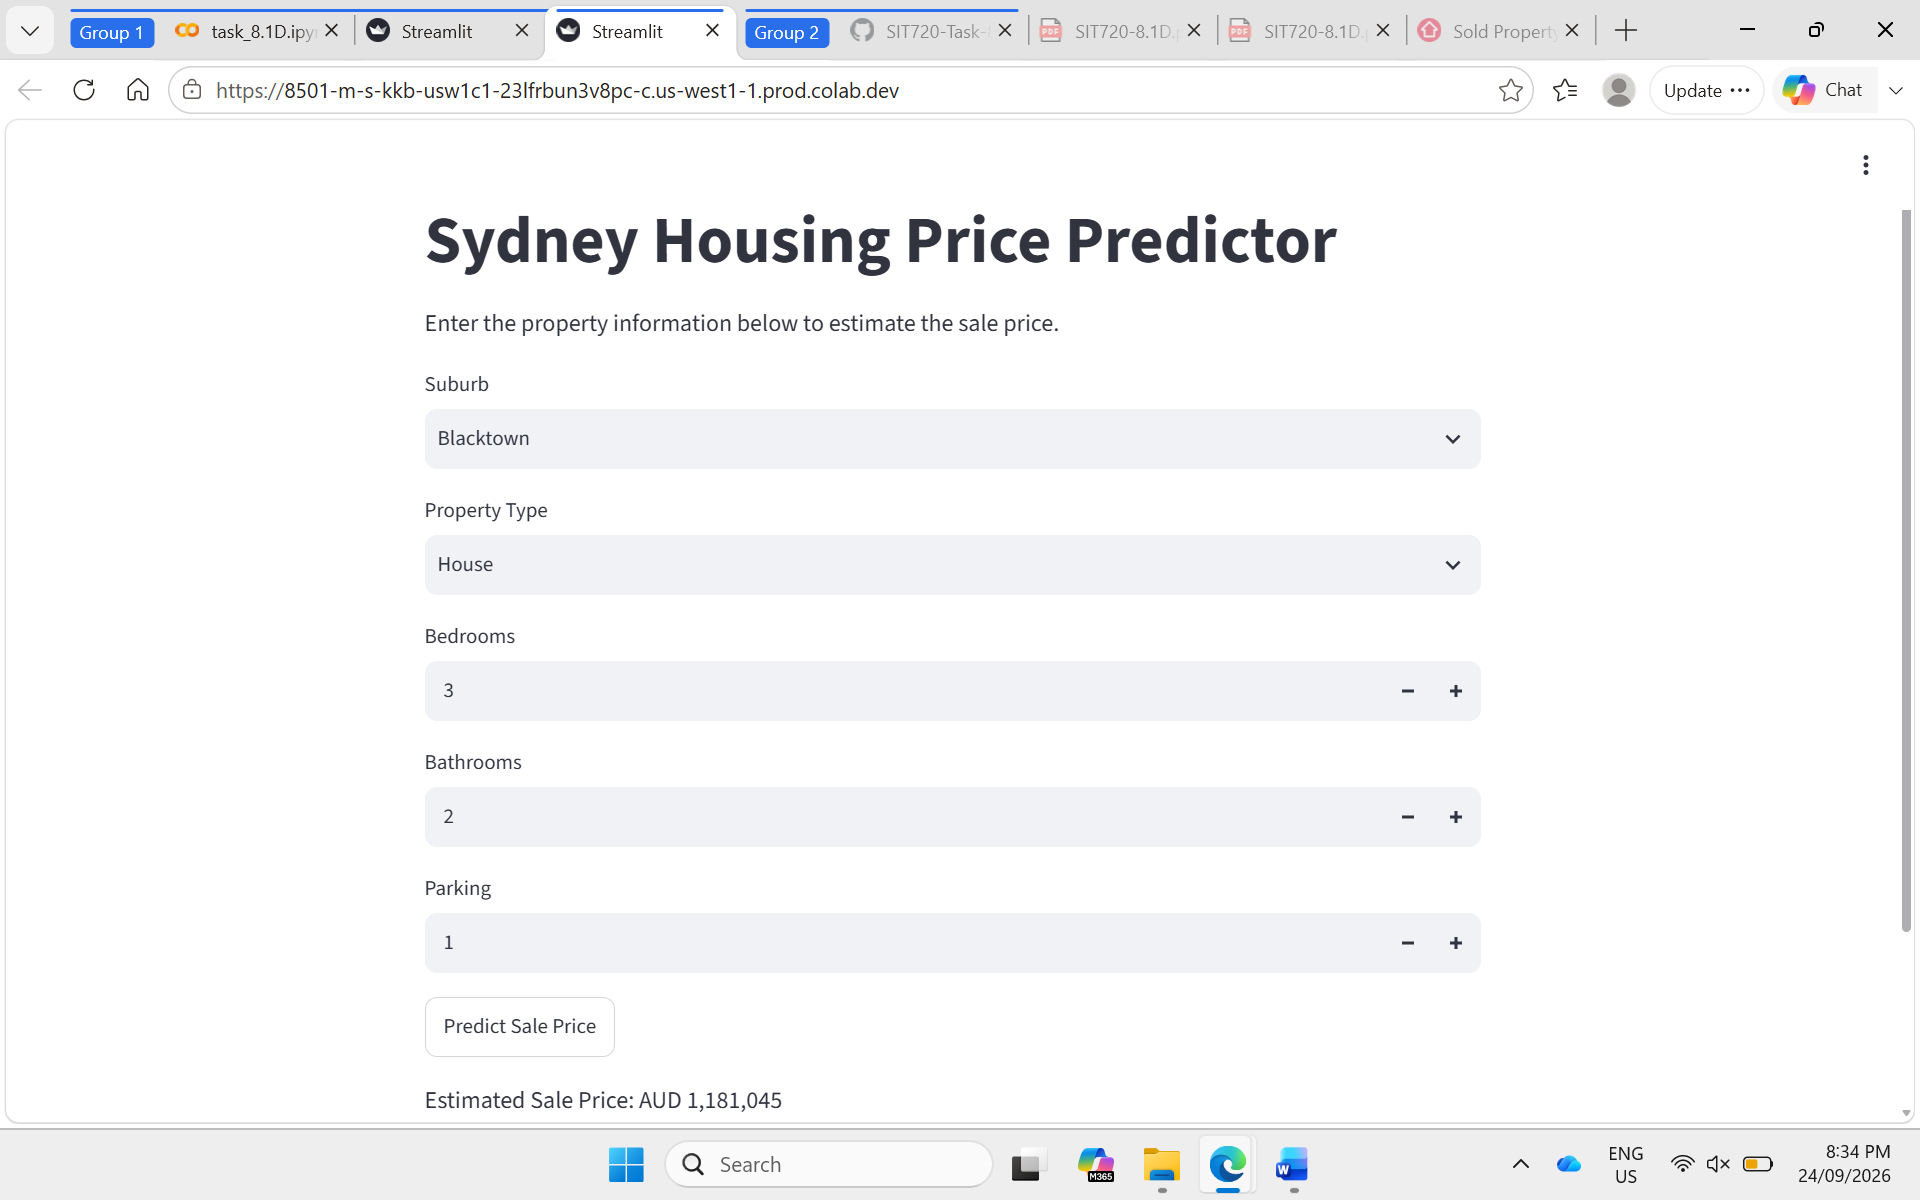

### Critical Reflection

This project helped me understand the full machine learning process, from collecting the housing data to building and deploying a prediction model. One of the main challenges was collecting the data because some properties did not have complete information. Land size, floor area and year built had many missing values, so I decided not to use them in the final models.

Exploring the data also showed me that housing prices can vary a lot even when properties have similar features. Some unusual and expensive properties were difficult for the models to predict. This showed me that having more relevant features and a larger dataset could improve the predictions.

When developing the models, I compared Linear Regression, Decision Tree and Random Forest. Linear Regression was simple but had a higher prediction error. The Decision Tree performed better but showed signs of overfitting because its training error was much lower than its cross-validation error. Random Forest gave the best overall cross-validation results, so I selected it as the final model.

Deploying the model with Streamlit also showed me that a machine learning model needs more than good results. The application had to take the user's inputs and convert them into the same format used during training. Keeping the application simple made it easier for a user to enter property information and understand the predicted price.

Bias is also important in this project because the dataset only contains properties from three Sydney suburbs. The data may not represent other suburbs or the wider Sydney housing market. There are also different property types in each suburb, which may affect the predictions.

The predicted prices should only be used as estimates and not as exact property values. A wrong prediction could affect someone's decision about buying or selling a property. For this reason, the model should be used together with other property information and human judgement.

If I had more time and data, I would collect more properties from each suburb and include more useful features such as land size, floor area, year built and property condition. I would also include more Sydney suburbs so the model could be used for a wider range of properties.

I would also test the model with more data and continue improving its performance. Overall, this project showed me that the quality of the data is very important. A more complex model does not always solve the problem if important information is missing from the dataset.